<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensorflow Implementation

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.1037 - val_loss: 0.0731
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0718 - val_loss: 0.0699
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0693 - val_loss: 0.0678
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0679 - val_loss: 0.0671
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0670 - val_loss: 0.0662
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0663 - val_loss: 0.0657
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0658 - val_loss: 0.0651
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0653 - val_loss: 0.0647
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0650 - val_loss: 0.0644
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0647 - val_loss: 0.0642
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0644 - val_loss: 0.0638

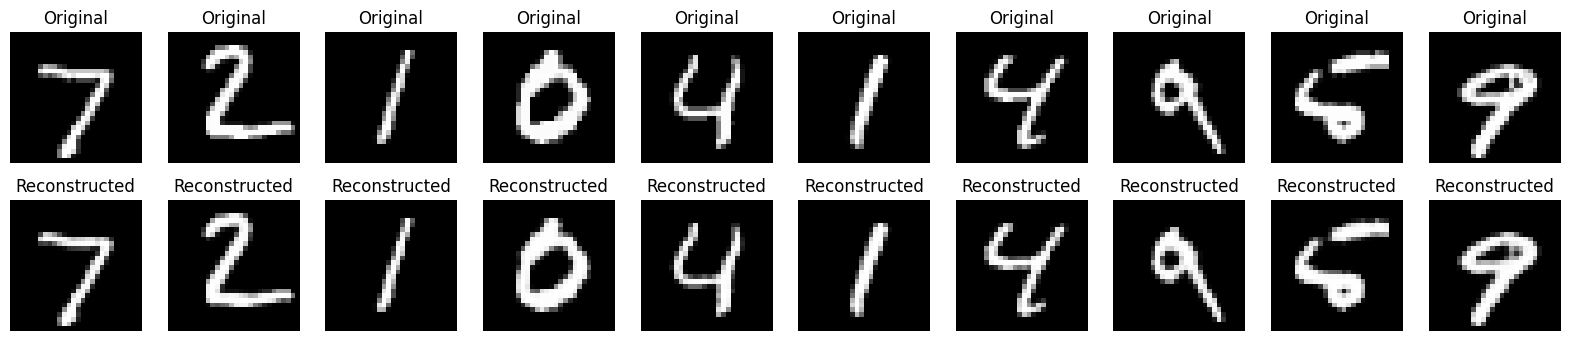

In [1]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset (MNIST)
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Define Autoencoder
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Predict
decoded_imgs = autoencoder.predict(x_test)

# Visualize
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title("Original")

    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title("Reconstructed")
plt.show()

# PyTorch Implementation

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),

            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [4]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1152
Epoch 2, Loss: 0.0731
Epoch 3, Loss: 0.0705
Epoch 4, Loss: 0.0691
Epoch 5, Loss: 0.0683
Epoch 6, Loss: 0.0676
Epoch 7, Loss: 0.0670
Epoch 8, Loss: 0.0665
Epoch 9, Loss: 0.0662
Epoch 10, Loss: 0.0658


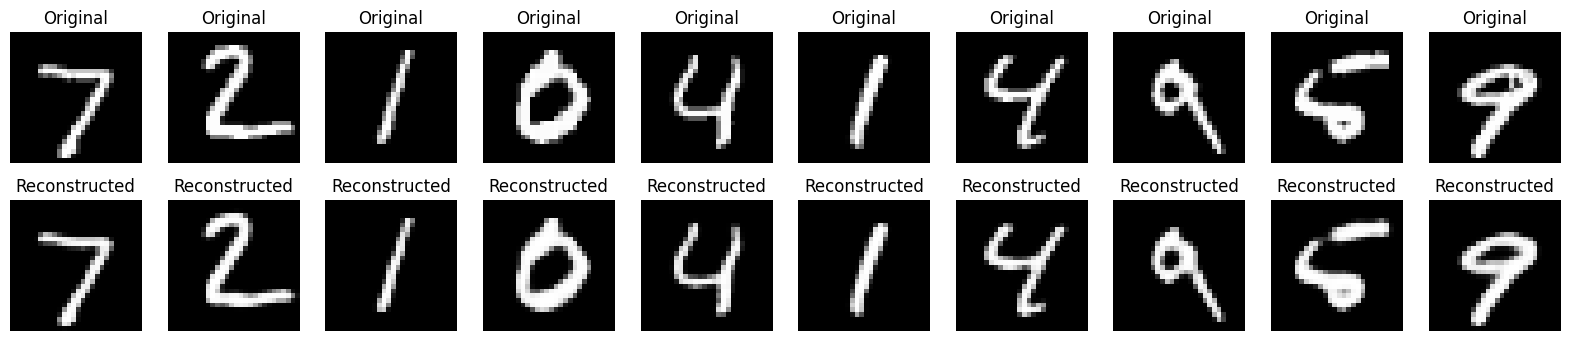

In [5]:
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    outputs = model(test_images)

# Move to CPU
test_images = test_images.cpu()
outputs = outputs.cpu()

# Plot
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(test_images[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title("Original")

    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title("Reconstructed")
plt.show()

# TASK: Improved Model (Better Architecture)

In [10]:
class ImprovedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 28 -> 14

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 14 -> 7

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),  # 7 -> 14

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),  # 14 -> 28

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [11]:
import math

def train_autoencoder(model, train_loader, test_loader, epochs=10, lr=1e-3, device="cuda"):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_mse": [],
        "test_psnr": []
    }

    for epoch in range(epochs):
        # ------------------
        # TRAIN
        # ------------------
        model.train()
        total_train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # ------------------
        # TEST / EVALUATE
        # ------------------
        model.eval()
        total_test_loss = 0.0
        total_mse = 0.0

        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                outputs = model(images)

                loss = criterion(outputs, images)
                mse = torch.mean((outputs - images) ** 2)

                total_test_loss += loss.item()
                total_mse += mse.item()

        avg_test_loss = total_test_loss / len(test_loader)
        avg_mse = total_mse / len(test_loader)

        # PSNR assumes images are normalized to [0, 1]
        psnr = 10 * math.log10(1.0 / avg_mse)

        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_mse"].append(avg_mse)
        history["test_psnr"].append(psnr)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train BCE: {avg_train_loss:.4f} | "
            f"Test BCE: {avg_test_loss:.4f} | "
            f"Test MSE: {avg_mse:.6f} | "
            f"PSNR: {psnr:.2f} dB"
        )

    return model, history

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

basic_model = Autoencoder()
improved_model = ImprovedAutoencoder()

basic_model, basic_history = train_autoencoder(
    basic_model,
    train_loader,
    test_loader,
    epochs=10,
    lr=1e-3,
    device=device
)

improved_model, improved_history = train_autoencoder(
    improved_model,
    train_loader,
    test_loader,
    epochs=10,
    lr=1e-3,
    device=device
)

Epoch [1/10] Train BCE: 0.1109 | Test BCE: 0.0735 | Test MSE: 0.004187 | PSNR: 23.78 dB
Epoch [2/10] Train BCE: 0.0723 | Test BCE: 0.0700 | Test MSE: 0.003156 | PSNR: 25.01 dB
Epoch [3/10] Train BCE: 0.0699 | Test BCE: 0.0685 | Test MSE: 0.002678 | PSNR: 25.72 dB
Epoch [4/10] Train BCE: 0.0686 | Test BCE: 0.0674 | Test MSE: 0.002396 | PSNR: 26.20 dB
Epoch [5/10] Train BCE: 0.0677 | Test BCE: 0.0667 | Test MSE: 0.002164 | PSNR: 26.65 dB
Epoch [6/10] Train BCE: 0.0670 | Test BCE: 0.0662 | Test MSE: 0.002067 | PSNR: 26.85 dB
Epoch [7/10] Train BCE: 0.0665 | Test BCE: 0.0656 | Test MSE: 0.001863 | PSNR: 27.30 dB
Epoch [8/10] Train BCE: 0.0660 | Test BCE: 0.0655 | Test MSE: 0.001801 | PSNR: 27.44 dB
Epoch [9/10] Train BCE: 0.0656 | Test BCE: 0.0649 | Test MSE: 0.001662 | PSNR: 27.79 dB
Epoch [10/10] Train BCE: 0.0653 | Test BCE: 0.0646 | Test MSE: 0.001613 | PSNR: 27.92 dB
Epoch [1/10] Train BCE: 0.0798 | Test BCE: 0.0670 | Test MSE: 0.002258 | PSNR: 26.46 dB
Epoch [2/10] Train BCE: 0.0654 

In [13]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Basic Autoencoder", "Improved Autoencoder"],
    "Final Train BCE": [
        basic_history["train_loss"][-1],
        improved_history["train_loss"][-1]
    ],
    "Final Test BCE": [
        basic_history["test_loss"][-1],
        improved_history["test_loss"][-1]
    ],
    "Final Test MSE": [
        basic_history["test_mse"][-1],
        improved_history["test_mse"][-1]
    ],
    "Final Test PSNR": [
        basic_history["test_psnr"][-1],
        improved_history["test_psnr"][-1]
    ]
})

comparison

,Model,Final Train BCE,Final Test BCE,Final Test MSE,Final Test PSNR
0,Basic Autoencoder,0.065299,0.064646,0.001613,27.922904
1,Improved Autoencoder,0.061113,0.060550,0.000551,32.587897


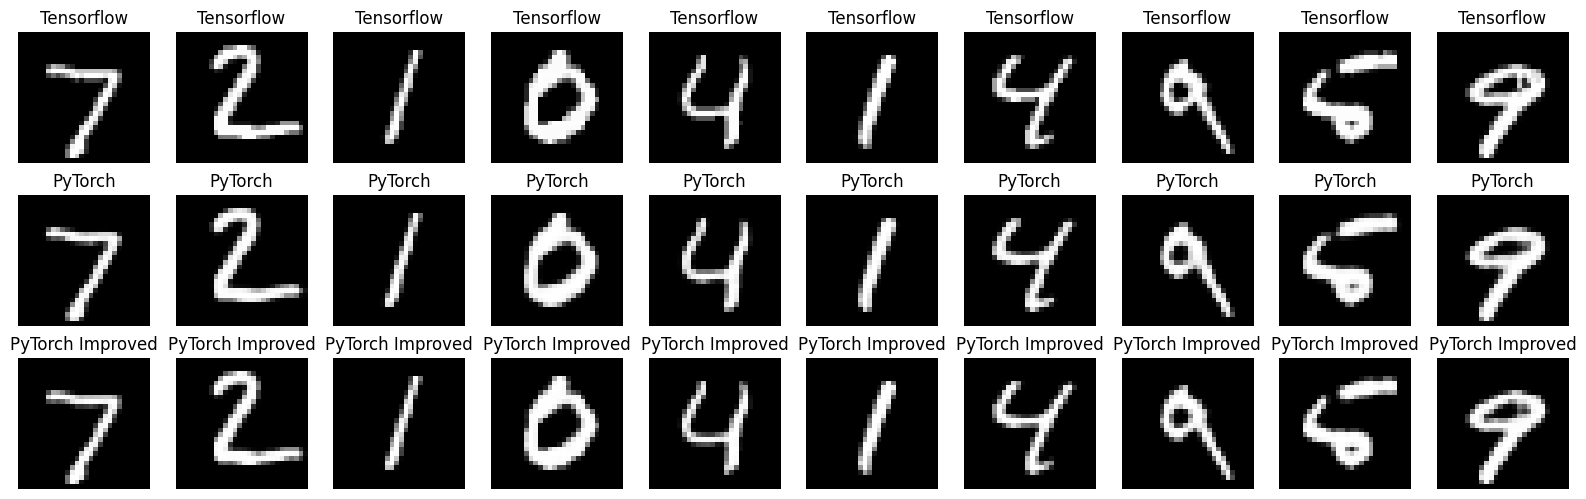

In [15]:
import matplotlib.pyplot as plt

basic_model.eval()
improved_model.eval()

with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)

    basic_outputs = basic_model(test_images)
    improved_outputs = improved_model(test_images)

test_images = test_images.cpu()
basic_outputs = basic_outputs.cpu()
improved_outputs = improved_outputs.cpu()

n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(test_images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Tensorflow")

    # Basic reconstruction
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(basic_outputs[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("PyTorch")

    # Improved reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(improved_outputs[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("PyTorch Improved")

plt.show()